In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/TP_Python/lab-5/"

Mounted at /content/drive
/content/drive/MyDrive/TP_Python/lab-5


# The Vicsek model

The Vicsek model is also called the flying XY-model and was introduced with the aim to answer the question **what are the simple underlying *!!local!!* rules which allow big groups of animals (also called agents) to move collectively**. Immediate examples, are schools of fish, herds of quadrupeds, or flocks of flying birds. The emphasis is really on **local rules**, meaning we do **not** consider some outside observer that dictates the individual agents what to do. Instead **every agent** makes decisions based on it's immediate **local** environment. The model is composed of simple rules, that each agent follows, leading to interesting **collective phenomena**, like the ones observed in nature.  
<img src='https://drive.google.com/uc?id=125dDDczIFB6RF1leJuwriwSiDuabbskl'>  

## The rules

We consider a system of total $N$ agents (i.e., birds, fish, etc.). Each agent $i$ is defined by a position $\vec{r}_i(t)$ and moves with a constant speed $v_i = v_0$. **The key ingredient** of the model is the orientation $\theta_i(t)$ of the velocity $\vec{v}_i(t) = v_0 \,\vec{e}(\theta_i(t))$, with $\vec{e}(\theta_i(t)) = [\,\cos\theta_i(t)\,,\, \sin\theta_i(t)\,\,]$ in two dimensions. What we need next is an **update** rule for the orientation $\theta_i(t)$, i.e., how does the orientation change in time. So we consider a bird; this bird can see only a certain distance away. Or in other words, it has a vision in the radius $r_{\rm vision}$ around itself. As long as there is no other bird in its vision radius it flies with a constant speed $v_0$ and with the orientation updated as:

$\theta_i(t+\Delta t) = \theta_i(t) + \Delta \theta$,  

where $\Delta \theta$ is what we call a **noise** term. How to think about this term? Imagine a lonely bird flying; it will **not** fly in a perfectly straight line but instead it will constantly change its orientation. Without any other information about the environment the bird is flying in, we write that $\Delta \theta$ is a random number coming from a uniform distribution centered around 0 and with a width $\eta$, i.e.,

$\Delta\theta\in [-\eta/2,\,+\eta/2]$.  

Let us now make the bird be a part of a flock of birds, and say it starts flying at $t=t_0$ with $\theta_i(t_0)$. At some later time $t_1 > t_0$ the bird starts seeing other birds as **they enter its vision radius**. To avoid crashing, the bird will **align its orientation** with the average direction of motion of other birds it sees. Likewise, the other birds will do the same as long as they have other birds (agents) in their vision radius. Let us assume that the birds can see anyone within $360^\circ$. Becasue our bird is now flying in a flock, we can follow what is happening with it and with the flock by updating the orientation and position of each bird as follows:
  
$\theta_i(t+\Delta t) = \langle\,\theta_j(t)\,\rangle_{|\vec{r}_i(t)-\vec{r}_j(t)| < r_{\rm vision}} + \Delta \theta$  
  
$\vec{r}_i(t+\Delta t) = \vec{r}_i(t) + \Delta t \, v_0 \vec{e}(\theta_i(t))$.  
  
Here $\langle\,\theta_j(t)\,\rangle_{|\vec{r}_i(t)-\vec{r}_j(t)| < r_{\rm vision}}$ is the average orientation of all the birds $j$ in the vision radius of the bird $i$, i.e., $|\vec{r}_i(t)-\vec{r}_j(t)| < r_{\rm vision}$, which of course includes the bird $i$ as well. In other words, the calculation of the average orientation should include the orientation of the bird $i$ also.

## The results of this model

The following plot (from the original publication of Vicsek et al., Physical Review Letters. 75 (6): 1226–1229 (1995)) shows snapshots of short trajectories of a flock of agents. The set of parameters is chosen such that we can see several different behaviours of the system.

In the publication, the following parameters were fixed: the vision radius $r_{\rm vision}$ (set to 1), the speed $v_0$ (set to 1), the time discretization $\Delta t$ (set to 0.03), as well as the number of agents $N$ (set to 300 in the plots below). The parameters that were varied are: the density $\rho = N / V$ and the noise strength $\eta$.

In panel b) you can see how, for small densities and noise, the agents tend to form groups moving coherently in random directions (the values taken were $\rho = 0.244$, $\eta = 0.1$).

In panel c) you can see how, at higher densities and noise ($\rho = 6.122$, $\eta = 2.0$), the agents move randomly with some correlation.  

Finally, in panel d) you can see how, for higher density and small noise ($\rho = 12$, $\eta = 0.1$), the motion of agents becomes ordered.  
<img src='https://drive.google.com/uc?id=1gBwb1xT1t9EKI_pcgsycfnDswedB2Rc3' width="500">  

**The exciting point for physicists** is that the model shows a **phase transition** from a disordered state (agents move in random directions) to an ordered state (agents move collectively in the same direction). The associated **order parameter** is the absolute value of the average normalized velocity:  

$v_{\rm a} = \frac{1}{N v_0}\left\lvert \sum_{i = 1}^N \vec{v}_i \right\rvert$.

To give you an idea of what this means: if $v_{\rm a} = 0$ there is no order in the system, and if $v_{\rm a} = 1$ the system is fully ordered (all agents move in the same direction). The following image from the original publication shows the phase transition in a system at constant density $\rho$ but for different noise strengths $\eta$:  
<img src='https://drive.google.com/uc?id=1oRtvliPW1R_VtXtnfKEUrWR0XR3C6Czn' width="300">  

In the figure you can see that the system size $N$ is also varied, and that the change of the order parameter $v_{\rm a} = 0$ to $v_{\rm a} > 0$ becomes sharper and sharper as $N$ increases. These are the so-called finite-size effects. As physicists we are interested in the **thermodynamic limit**, meaning $N,V \to \infty$, while $\rho = N/V$ finite! The red line indicates what the phase transition would look like in the **thermodynamic limit**.

## A few things before we start simulating the Vicsek model:

### Are you familiar with periodic boundary conditions?

Your task will be to simulate active (Vicsek) particles in 2-dimensions, and some of the things you will need to specify are the shape, size and boundary conditions of the simulation area particles live in. Assume you will be working with a rectangular box $V = L_x\times L_y$. Regarding the boundaries conditions, there are two possibilities --- periodic or non-periodic.  
Periodic boundaris are extremly useful concept in physics, used to reduce the *finite-size effects*. As already mentioned, we are interested in how the system behaves in the thermodynamic limit, i.e., with $N,V \to \infty$ while $\rho = \frac{N}{V}$ stays finite. As we cannot simulate $N \to \infty$ particles, even if our $N$ is really large, it is only an approximation of the thermodynamic limit and we will see finite-size effects. **We can reduce those finite-size effects with periodic-boundary conditions.**

Non-periodic (or fixed) boundaries correspond to the real world --- if a particle moves in the direction of the box wall, at some point it will collide with it and bounce back (will be reflected back).

As in the original paper we will work with periodic boundary conditions. And we will need them when encountering a situation where a circle with $r_{\text{vision}}$ around particle $i$ goes outside the box area. So your first task is to write a function that calculates distance between two particles and uses periodic boundary conditions. Do this first in 1-dimension and then in 2.

- Consider a 1-dimensional system where particles live on the $x$-axis. The system is confined so that $x\in [0,L_x]$. Periodic boundaries mean that $x = 0$ is the same as $x = L_x$. In other words, in one dimension, periodic boundaries mean the system lives on a ring of perimeter $L_x$. Write a function that calculates the *shortest* distance between two particles.

In [2]:
### your code here ###
import numpy as np


def PeriodicDistance1D(x1,x2,L):
  return min(abs((x1-x2)%L),abs((x2-x1)%L))
#We wish for a positive value in the end, and we try both "directions" considering the fact that the distance can be calculated with the periodic "loop" at the borders

In [3]:
# Test the function on these values; we use "PeriodicDistance1D" for the name of the function
L_x = 10.
x_1 = 1.2 #try x_1 = 8.7 or 1.2
x_2 = 9.6
print('The shortest distance between the particles is', PeriodicDistance1D(x_1, x_2, L_x))

The shortest distance between the particles is 1.5999999999999996


- Now consider a 2-dimensional system, where particles positions $\vec{r}_i$ are given by their $x\vec{e}_x$ and $y\vec{e}_y$ coordinates in a periodic box of length $L_x=L_y$. Write a function that calculates the shortest distance between two particles and test it such that you get $|\vec{r}_1 - \vec{r}_2 | = \sqrt{2^3}\approx 2.8284$ for $\vec{r}_1 = [1,1]$ and $\vec{r}_2 = [9,9]$ and $L_x = L_y = 10$. Note that there are useful numpy functions you can use like np.linalg.norm, np.minimum.

In [4]:
### your code here ###

def PeriodicDist(pos1,pos2,BoxSize):
  return np.linalg.norm(np.array([PeriodicDistance1D(pos1[0],pos2[0],BoxSize[0]),PeriodicDistance1D(pos1[1],pos2[1],BoxSize[1])]))
#We use the previously defined PeriodicDistanceD to find the shortest distance on the x and y axis individually while taking priodicity into account, and then we take the norm of it.

In [5]:
# Test the function on these values; we use "PeriodicDist" for the name of the function;
L_x = 10.
L_y = 10.
SimulationBoxSize = [L_x, L_y]
pos_1 = np.array([ 1., 1.])
pos_2 = np.array([ 9., 9.])
print('The shortest distance between the particles is', PeriodicDist(pos_1, pos_2, SimulationBoxSize))

The shortest distance between the particles is 2.8284271247461903


### Do you know how to compute the mean of a circular quantity?

Next, you need to write a function that will calculate a **mean of a circular quantity**. So it is not an arithmetic mean i.e., an arithmetic mean of $0^\circ$ and $360^\circ$ is $180^\circ$, which is misleading because $360^\circ$ is the same thing as $0^\circ$. Instead, given the angles $\alpha_1,\,\alpha_2,\,\dots,\,\alpha_n$ a common formula for a mean of a circular quantity is:

$\bar{\alpha} = \arg\left(\sum_{j = 1}^n \exp(i\,\alpha_j)\right),$  

where $i$ is the imaginary unit and $\arg(z) = \phi$ the argument in radians of a complex number $z = r\exp(i \phi) = r(\cos \phi + i \, \sin \phi) = x + i \,y$.  

Your task is to write the function for the circular mean; keep in mind that there are a number of useful numpy functions you can use, e.g., np.exp(), np.sum(), np.angle(), np.radians(), and the imaginary unit in python is 1j.

In [6]:
### your code here ###

def CircularMean(AngList):
  return np.angle(np.sum([np.exp(1j*(angle)) for angle in AngList]))
#We calculate the average as given in the formula, by summing a list of exp(1j*angles)

In [7]:
# Test the function on these values; we use "CircularMean" for the name of the function

AngleListInDegree = [0, 0, 90]
AngleListInRad = np.radians(AngleListInDegree)
TheCircularMean = CircularMean(AngleListInRad)
print('Circular mean in degree: %.3f' %  np.degrees( TheCircularMean ) )
print('Test for [0, 0, 90]: Your function is right if you get zero here: %.3f' % (TheCircularMean-0.4636476090008061))

AngleListInDegree = [0,181]
AngleListInRad = np.radians(AngleListInDegree)
TheCircularMean = CircularMean(AngleListInRad)
print('Circular mean in degree: %.3f' %  np.degrees( TheCircularMean ) )
print('Test for [0, 181]! Your function is right if you get zero here: %.3f' % (TheCircularMean+1.5620696805349268))

AngleListInDegree = [0, 355]
AngleListInRad = np.radians(AngleListInDegree)
TheCircularMean = CircularMean(AngleListInRad)
print('Circular mean in degree: %.3f' %  np.degrees( TheCircularMean ) )
print('Test for [0, 355]! Your function is right if you get zero here: %.3f' % (TheCircularMean+0.04363323129985831))


Circular mean in degree: 26.565
Test for [0, 0, 90]: Your function is right if you get zero here: 0.000
Circular mean in degree: -89.500
Test for [0, 181]! Your function is right if you get zero here: 0.000
Circular mean in degree: -2.500
Test for [0, 355]! Your function is right if you get zero here: 0.000


## Code the Vicsek-model !

Your goal is to simulate moving particles (point particles that you will depict as elipses) in a periodic box, that align following the update rules for the orientations $\theta_i(t+\Delta t)$ and positions $\vec{r}_i(t+\Delta t)$ defined above.

The orientations of all particles are updated at the same moment, i.e., the average $\langle\,\theta_j(t)\,\rangle_{|\vec{r}_i(t)-\vec{r}_j(t)| < r_{\rm vision}}$ depends on the values $\theta_j(t)$ and $\vec{r}_j(t)$ at time $t$ and not $t + \Delta t$! In the same manner, the positions need to be updated at the same moment as the orientations. This means that you need to keep a list of orientations at time $t$ while you are calculating orientations and positions at $t+\Delta t$. At the beginning play with very small system sizes, say $N=25$ particles. The time it takes to calculate $\langle\,\theta_j(t)\,\rangle$ scales as $N^2$, i.e., it grows fast.

You are first going to focus on visualization of your system.

### Import libraries for the animation

In [8]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
from matplotlib.collections import EllipseCollection
from IPython.display import HTML

### Define the system parameters, initialize the system and plot it

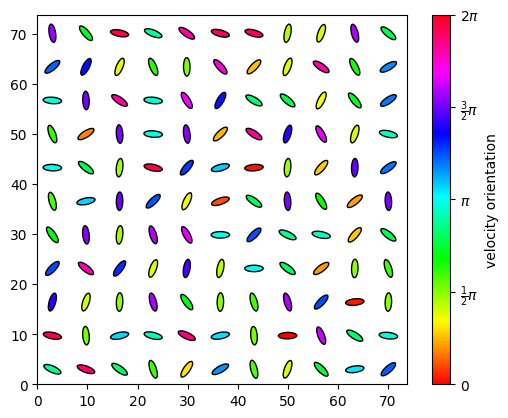

In [9]:
### your code here ###
# Define N and calculate the size of the simulation box from the values of N and density rho
# For the density use rho = 0.244 (you can vary the density later)

FacteurDeTaille = 3 # This only serves as a parameter to upscale figures without losing readability
N = 121

rho = 0.2

V = N/rho
L = FacteurDeTaille*np.sqrt(V) #L being the limit of the "box" for both x and y

# The parameters of the Vicsek model are
v_0 = FacteurDeTaille*0.5   #<--- initial speed of the particles, I find that 0.5 or 0.35 makes their movement more visible than 1
dt = 0.005  #<--- time discretization
eta = 0.3  #<--- noise strength on the angle
visionRadius = FacteurDeTaille*1.0 #<--- the vision radius

# Define the initial positions of the N particles on a regular lattice; a useful function for this
# is np.meshgrid(x, y)

LatticeX,LatticeY = np.arange(3,L,L/np.sqrt(N)),np.arange(3,L,L/np.sqrt(N))
InitialX,InitialY = np.meshgrid(LatticeX,LatticeY)

# Choose random initial orientations of the particles

Orientations = np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))



#Plotting of initial state :

fig, ax = plt.subplots()
ax.set_xlim(0,L)
ax.set_ylim(0,L)
ax.set_aspect('equal')
#<---- defining look, positions and orientations of particles


Width = 0.05*L*np.ones(N) # here 3 is simulation box size
Height = 0.35*Width
Angle = np.degrees(Orientations) # in degrees

Coordinates = np.column_stack((InitialX.ravel(), InitialY.ravel()))


collection = EllipseCollection(Width, Height, Angle, units='x', offsets=Coordinates,
                       transOffset=ax.transData, cmap='hsv', ec = 'k')
collection.set_array((Orientations).ravel()) # sets the color of each particle
collection.set_clim(0, 2.*np.pi) # sets the range for the colors
ax.add_collection(collection) #<---- we add our collection to the plot
#<---- we define the color bar
cbar = plt.colorbar(collection, ticks=[0, np.pi*0.5, np.pi, np.pi*1.5, np.pi*2])
cbar.set_ticklabels(['$0$', '$\\frac{1}{2}\\pi$', '$\\pi$', '$\\frac{3}{2}\\pi$', '$2\\pi$'])
cbar.set_label('velocity orientation')
plt.show() # show the inital configuration

### The function that updates the velocities and positions, and each frame/image of the animation

In [10]:
import matplotlib

## CONVENTIONS


#Orientation_data is a list of numpy arrays for orientations, each array representing an instant t
#Coord_X and Coord_Y serve to keep in memory all of the coordinates for every instant : they are both lists of numpy arrays
#Coord_data_ellipses solely serves to define the working agent and compute the images at the end, and is a list of np.column_stack arrays


def updateFrame(frame,Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y):

  ### Value-holding lists
  New_Orientation = [] #New_Orientation is a list containing the next orientation at t+ for every point
  New_Coord_ellipses = []  #New_Coord is a list containing the next coordinates as a np.column_stack([x,y]) for all agents at t+
  New_Coord_X,  New_Coord_Y  = [], [] #Likewise, but only as lists
  i = 0 # counter to know where we are in the linear lists

  for Coord in Coord_data_ellipses[-1] : #Computing for every point/agent
    X,Y = Coord[0],Coord[1]

    ### UPDATING : Angles
    Distances_considered = np.array([PeriodicDist(Coord,Coord_data_ellipses[-1][j],[L,L]) for j in range(len(Coord_data_ellipses[-1]))]) #Getting all the distances between agents, including the one considered
    Angles_considered = np.where(Distances_considered <= visionRadius,Orientation_data[-1], None) #Get all the angles of the points in the observation radius of the selected agent
    Angles_considered = Angles_considered[Angles_considered != None] #Removing all iterations of 'None', so the computation can run properly

    Noise = np.random.uniform(-eta/2,eta/2)
    New_Angle = CircularMean(Angles_considered)
    New_Orientation.append(New_Angle + Noise)

    ### UPDATING : position

    AngleOfAgent = Orientation_data[-1][i] #Getting the angle of the working agent
    i += 1

    New_Coord_X.append((X+v_0*np.cos(AngleOfAgent))%L)
    New_Coord_Y.append((Y+v_0*np.sin(AngleOfAgent))%L)

  ### Saving all the data for t+

  Coord_X.append(np.array(New_Coord_X))
  Coord_Y.append(np.array(New_Coord_Y))
  Orientation_data.append(np.array(New_Orientation))
  Coord_data_ellipses.append(np.column_stack((np.array(New_Coord_X),np.array(New_Coord_Y))))

  ### Updating the figure

  #I'm force clearing the previous frame here so that I can see the particules moving, and not have to see every particule on top of each other for every computed time.
  ax.cla()
  ax.set_xlim(0,L)
  ax.set_ylim(0,L)
  ax.set_aspect('equal')
  #I do not know if there is a working method to only remove 'collection', as trying collection.remove() only gives me an error "list.remove(x) x not in list"

  collection = EllipseCollection(Width, Height, np.degrees(Orientation_data[-1]), units='x', offsets=Coord_data_ellipses[-1],transOffset=ax.transData, cmap='hsv', ec = 'k')
  collection.set_array((Orientation_data[-1]).ravel())
  ax.add_collection(collection)
  return fig,

### The code below does the animation as a HTML video

In [ ]:
##Initializing coordinates and orientations

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

### Write code that saves the animation as a mp4 file; in parallel you can measures the time it takes to create the frames. Make 100 frames, with 24fps (frames per second)

In [11]:
### your code here ###


# Saving the animation :
#ani.save('Vicsek_animation.mp4', fps=NumberOfFrams, extra_args=['-vcodec', 'libx264'])

import time
start_time = time.time()

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 1000/24
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())


print("For N = ", N, " code runs for %s seconds."%(time.time() - start_time))

For N =  121  code runs for 31.5864839553833 seconds.


Once you have all this coded your additional tasks are the following:

- Write a code that saves an image of the final configuration.  
- Save some representative images of configurations in the steady state in the parameter regions of flocking, disorder, and order.   
- Start from an initial configuration, where the positions are distributed randomly in the simulation box instead of on a grid. Save images of the steady-state configurations in the three regions. Compare them and explain if you see a difference.  


- Measure the average time for the update of one frame $T_{\rm frame}$ as a function of the system size $N$.
- Plot $T_{\rm frame}$ vs. $N$. What is the scaling of $T_{\rm frame}(N)$ and why?
- Can you think of how we could acheive $T_{\rm frame}(N) \propto N$? Write your response.  

- Animations are a great way to check if your code works. However, the generation of the images is too slow to do real measurements on your system. Write a new function that only updates the positions and orientations.
- Write a simulation **without** animation to reproduce the plot of the average normalized velocity as a function of the noise strength (attention: no need to have so many data points and you can stop at $N = 400$). Also keep in mind that you should wait for your system to reach the steady state (it must forget the initial configuration) before you start your measurements.

In [ ]:
### Final configuration, order
### For an ordered steady state, i.e. every single agent in the same direction, we diminish the noise term and increase the vision radius

# Parameters

N = 121
rho = 0.2
eta = 0.001
visionRadius = FacteurDeTaille*4.0
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

#plt.show()
#plt.savefig('Vicsek_fig_order.png')

### For some reason I do not understand, using "plt.show()" as written above does not print out the last frame of the animation, like it did in AnimationExamples.ipynb.
### I chose to simply use screen captures of the animations' last frames instead of taking more time to find a way to make this work.

In [ ]:
### Final configuration, flocking
### The flocking steady state was already reached with the parameters I experimented with above, thus I am keeping the same values, i.e. in-between for noise and vision radius.

# Parameters

N = 121
rho = 0.2
eta = 0.3
visionRadius = FacteurDeTaille*1.0
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

### Same comment as above
#plt.show()
#plt.savefig('Vicsek_fig_flocking.png')

In [ ]:
### Final configuration, disorder
### the disordered steady state simply requires a high noise term and a low vision radius : the agents can never align

# Parameters

N = 121
rho = 0.2
eta = 0.6
visionRadius = FacteurDeTaille*0.3
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

### Same comment as above
#plt.show()
#plt.savefig('Vicsek_fig_disorder.png')

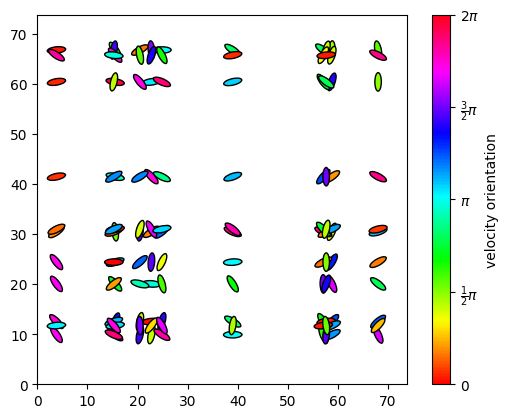

In [ ]:
### Randomized initial configuration

V = N/rho
L = FacteurDeTaille*np.sqrt(V)
NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
InitialX, InitialY = np.meshgrid(RandomX,RandomY)
# I do not know why np.random.uniform returns a list of a list here

# Choose random initial orientations of the particles

Orientations = np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))



#Plotting of initial state :

fig, ax = plt.subplots()
ax.set_xlim(0,L)
ax.set_ylim(0,L)
ax.set_aspect('equal')
#<---- defining look, positions and orientations of particles


Width = 0.05*L*np.ones(N) # here 3 is simulation box size
Height = 0.35*Width
Angle = np.degrees(Orientations) # in degrees

Coordinates = np.column_stack((InitialX.ravel(), InitialY.ravel()))


collection = EllipseCollection(Width, Height, Angle, units='x', offsets=Coordinates,
                       transOffset=ax.transData, cmap='hsv', ec = 'k')
collection.set_array((Orientations).ravel()) # sets the color of each particle
collection.set_clim(0, 2.*np.pi) # sets the range for the colors
ax.add_collection(collection) #<---- we add our collection to the plot
#<---- we define the color bar
cbar = plt.colorbar(collection, ticks=[0, np.pi*0.5, np.pi, np.pi*1.5, np.pi*2])
cbar.set_ticklabels(['$0$', '$\\frac{1}{2}\\pi$', '$\\pi$', '$\\frac{3}{2}\\pi$', '$2\\pi$'])
cbar.set_label('velocity orientation')
plt.show() # show the inital configuration

In [ ]:
### Final configuration, order, random initial positions

# Parameters

N = 121
rho = 0.2
eta = 0.001
visionRadius = FacteurDeTaille*4.0
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
InitialX, InitialY = np.meshgrid(RandomX,RandomY)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

### Same comment as above
#plt.show()
#plt.savefig('Vicsek_fig_order_randominit.png')

In [ ]:
### Final configuration, flocking, random initial positions

# Parameters

N = 121
rho = 0.2
eta = 0.3
visionRadius = FacteurDeTaille*1.0
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
InitialX, InitialY = np.meshgrid(RandomX,RandomY)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

### Same comment as above
#plt.show()
#plt.savefig('Vicsek_fig_flocking_randominit.png')

In [ ]:
### Final configuration, disorder, random initial positions

# Parameters

N = 121
rho = 0.2
eta = 0.6
visionRadius = FacteurDeTaille*0.3
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
InitialX, InitialY = np.meshgrid(RandomX,RandomY)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 40
ani = FuncAnimation(fig, updateFrame, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

### Same comment as above
#plt.show()
#plt.savefig('Vicsek_fig_disorder_randominit.png')

The randomization of the initial state does not seem to impact (much) the steady-state final result ; however, it seems to lengthen the duration of the transition state for the flocking parametrization.


In [12]:
### Tframe = f(N)

#I create a new UpdateFrame function, which will allow me to measure the average time it takes to update a frame with a list that I will average out at the end of the animation.

def UpdateFrameTime(frame,Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y,Time_list):

  start_time = time.time()

  ### Value-holding lists
  New_Orientation = [] #New_Orientation is a list containing the next orientation at t+ for every point
  New_Coord_ellipses = []  #New_Coord is a list containing the next coordinates as a np.column_stack([x,y]) for all agents at t+
  New_Coord_X,  New_Coord_Y  = [], [] #Likewise, but only as lists
  i = 0 # counter to know where we are in the linear lists

  for Coord in Coord_data_ellipses[-1] : #Computing for every point/agent
    X,Y = Coord[0],Coord[1]

    ### UPDATING : Angles
    Distances_considered = np.array([PeriodicDist(Coord,Coord_data_ellipses[-1][j],[L,L]) for j in range(len(Coord_data_ellipses[-1]))]) #Getting all the distances between agents, including the one considered
    Angles_considered = np.where(Distances_considered <= visionRadius,Orientation_data[-1], None) #Get all the angles of the points in the observation radius of the selected agent
    Angles_considered = Angles_considered[Angles_considered != None] #Removing all iterations of 'None', so the computation can run properly

    Noise = np.random.uniform(-eta/2,eta/2)
    New_Angle = CircularMean(Angles_considered)
    New_Orientation.append(New_Angle + Noise)

    ### UPDATING : position

    AngleOfAgent = Orientation_data[-1][i] #Getting the angle of the working agent
    i += 1

    New_Coord_X.append((X+v_0*np.cos(AngleOfAgent))%L)
    New_Coord_Y.append((Y+v_0*np.sin(AngleOfAgent))%L)

  ### Saving all the data for t+

  Coord_X.append(np.array(New_Coord_X))
  Coord_Y.append(np.array(New_Coord_Y))
  Orientation_data.append(np.array(New_Orientation))
  Coord_data_ellipses.append(np.column_stack((np.array(New_Coord_X),np.array(New_Coord_Y))))

  ### Updating the figure

  #I'm force clearing the previous frame here so that I can see the particules moving, and not have to see every particule on top of each other for every computed time.
  ax.cla()
  ax.set_xlim(0,L)
  ax.set_ylim(0,L)
  ax.set_aspect('equal')
  #I do not know if there is a working method to only remove 'collection', as trying collection.remove() only gives me an error "list.remove(x) x not in list"

  collection = EllipseCollection(Width, Height, np.degrees(Orientation_data[-1]), units='x', offsets=Coord_data_ellipses[-1],transOffset=ax.transData, cmap='hsv', ec = 'k')
  collection.set_array((Orientation_data[-1]).ravel())
  ax.add_collection(collection)

  # Adding the time needed to update this frame to the list of times measured

  Time_list.append(time.time() - start_time)

  return fig,

In [ ]:
### Here we use UpdateFrameTime to measure the average time needed to update a frame for a system of size N

Time_List = []

# Parameters, arbitrarily chosen to be the same as the flocking configuration

N = 121
rho = 0.2
eta = 0.3
visionRadius = FacteurDeTaille*1.0
V = N/rho
L = FacteurDeTaille*np.sqrt(V)

NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
InitialX, InitialY = np.meshgrid(RandomX,RandomY)

Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
Coord_X, Coord_Y = [InitialX],[InitialY]

## We use "updateFrame" for the name of the function you should have coded in the cell above (you can call it whatever you want
## just make sure to update the name in this cell);

NumberOfFrams = 100
Delay_in_ms = 1000/24
ani = FuncAnimation(fig, UpdateFrameTime, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y,Time_List), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
HTML(ani.to_html5_video())

AvgTime = sum(Time_List)/len(Time_List)
print("For a system of size N = ", N," the average time to update a frame is ", AvgTime, " seconds.")

For a system of size N =  121  the average time to update a frame is  0.18236630033738543  seconds.


[100, 121, 144, 169, 196, 225, 256, 289, 324, 361, 400] [0.14414506383461528, 0.17411684045697204, 0.22834961957270555, 0.30475369066295055, 0.3948875441409574, 0.5053863076880427, 0.6330202664479171, 0.7913574157374921, 0.9759646500691329, 1.2076939308997428, 1.4702543622196311]


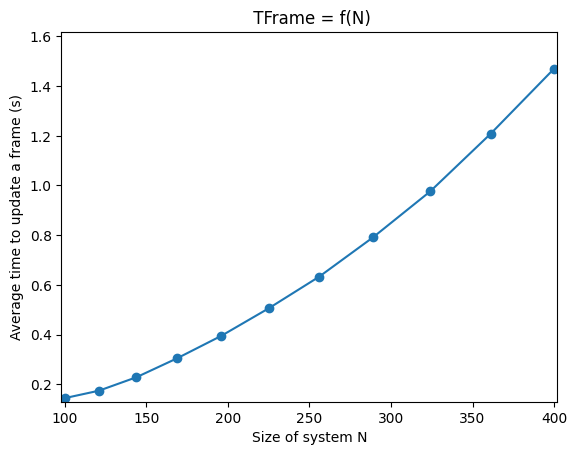

In [ ]:
### Here we compute perhaps a bit brutally all of the data needed to plot Tframe(N)

ListOfNs = []
ListOfTimes = []
Nmin = 10
Nmax = 20

# Parameters

rho = 0.2
eta = 0.3
visionRadius = FacteurDeTaille*1.0


NumberOfFrams = 100
Delay_in_ms = 1000/24


for N in range(Nmin,Nmax+1):

  N=N**2 #I find that using squared sizes helps with float to int conversions in computing

  Time_List=[]

  ### I reinitialize the entire figure so that there are no computing errors
  V = N/rho
  L = FacteurDeTaille*np.sqrt(V)

  NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
  RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
  InitialX, InitialY = np.meshgrid(RandomX,RandomY)

  Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
  Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
  Coord_X, Coord_Y = [InitialX],[InitialY]

  Orientations = np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))

  plt.close()
  fig, ax = plt.subplots()
  ax.set_xlim(0,L)
  ax.set_ylim(0,L)
  ax.set_aspect('equal')

  Width = 0.05*L*np.ones(N)
  Height = 0.35*Width
  Angle = np.degrees(Orientations)

  Coordinates = np.column_stack((InitialX.ravel(), InitialY.ravel()))

  collection = EllipseCollection(Width, Height, Angle, units='x', offsets=Coordinates,
                       transOffset=ax.transData, cmap='hsv', ec = 'k')
  collection.set_array((Orientations).ravel())
  collection.set_clim(0, 2.*np.pi)
  ax.add_collection(collection)

  cbar = plt.colorbar(collection, ticks=[0, np.pi*0.5, np.pi, np.pi*1.5, np.pi*2])
  cbar.set_ticklabels(['$0$', '$\\frac{1}{2}\\pi$', '$\\pi$', '$\\frac{3}{2}\\pi$', '$2\\pi$'])
  cbar.set_label('velocity orientation')

  ### Now we compute each point
  ani = FuncAnimation(fig, UpdateFrameTime, fargs=(Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y,Time_List), frames=NumberOfFrams, interval=Delay_in_ms, blit=False)
  HTML(ani.to_html5_video())

  AvgTime = sum(Time_List)/len(Time_List)

  ListOfNs.append(N)
  ListOfTimes.append(AvgTime)



### Plotting of the resulting TFrame(N)

plt.clf()
plt.cla() #Clearing the figures since they have been used to create the animations

print(ListOfNs,ListOfTimes)
plt.plot(ListOfNs,ListOfTimes, marker ='o')
plt.xlabel('Size of system N')
plt.ylabel('Average time to update a frame (s)')
plt.title(' TFrame = f(N)')
plt.xlim((Nmin**2)-2,(Nmax**2)+2)
plt.ylim(0.9*min(ListOfTimes),1.1*max(ListOfTimes))
plt.show()

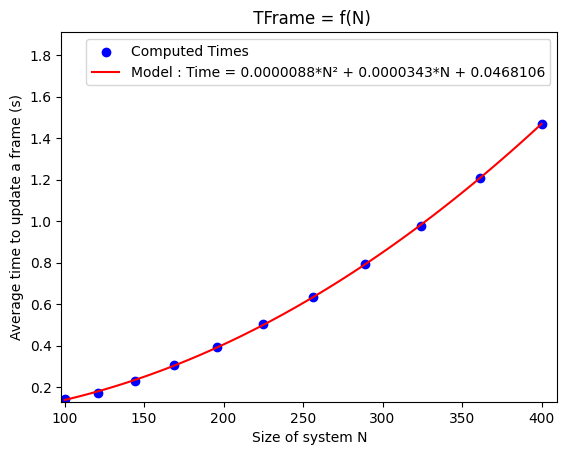

In [ ]:
### I use polyfit to get a model for TFrame(N)



ListOfComputedNs = [100, 121, 144, 169, 196, 225, 256, 289, 324, 361, 400]
ListOfComputedTimes = [0.14414506383461528, 0.17411684045697204, 0.22834961957270555, 0.30475369066295055, 0.3948875441409574, 0.5053863076880427, 0.6330202664479171, 0.7913574157374921, 0.9759646500691329, 1.2076939308997428, 1.4702543622196311]

coeff = np.polyfit(ListOfComputedNs,ListOfComputedTimes,2)


NMod = np.linspace(min(ListOfComputedNs),max(ListOfComputedNs),100)
Mod = [coeff[0]*val**2+ coeff[1]*val + coeff[2] for val in NMod]

plt.figure(1)
plt.scatter(ListOfComputedNs,ListOfComputedTimes, marker = "o", color = "blue", label = "Computed Times")
plt.plot(NMod, Mod, color = "red", label = f"Model : Time = {coeff[0]:.7f}*N² + {coeff[1]:.7f}*N + {coeff[2]:.7f}")
plt.xlabel('Size of system N')
plt.ylabel('Average time to update a frame (s)')
plt.title(' TFrame = f(N)')
plt.legend()
plt.xlim((Nmin**2)-2,(Nmax**2)+10)
plt.ylim(0.9*min(ListOfTimes),1.3*max(ListOfTimes))
#Changing from 1.1 to 1.3 and +2 to +10 as a lazy way to get more visibility of the legend
plt.show()

TFrame(N) seems to be parabolic according to the polyfit study of the computed data, not linear for N.

Since the code needs to update the position of every agent in relation to the other agents surrounding it, it seems unlikely that the code as defined can be linear for N. Maybe it could be if we used a model only taking into account the k closest neighbors of each agent, but as agents clump together, each influences others many times in the computation.


In [13]:
### Defining a Va function, where all of the speeds are already normalized by V0

def Va(Orientation_dataset,N):
  # Computing the x and y coordinates of the vector sum(Vi)
  X_coord = sum([np.cos(theta) for theta in Orientation_dataset])
  Y_coord = sum([np.sin(theta) for theta in Orientation_dataset])
  return (np.sqrt(X_coord**2 + Y_coord**2))/N

In [14]:
### New code without animation

# We will consider that steady-state is reached after around 120 frames.

def updateFrameNoAnim(frame,Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y,Vas_for_eta):

  ### Value-holding lists
  New_Orientation = [] #New_Orientation is a list containing the next orientation at t+ for every point
  New_Coord_ellipses = []  #New_Coord is a list containing the next coordinates as a np.column_stack([x,y]) for all agents at t+
  New_Coord_X,  New_Coord_Y  = [], [] #Likewise, but only as lists
  i = 0 # counter to know where we are in the linear lists

  for Coord in Coord_data_ellipses[-1] : #Computing for every point/agent
    X,Y = Coord[0],Coord[1]

    ### UPDATING : Angles
    Distances_considered = np.array([PeriodicDist(Coord,Coord_data_ellipses[-1][j],[L,L]) for j in range(len(Coord_data_ellipses[-1]))]) #Getting all the distances between agents, including the one considered
    Angles_considered = np.where(Distances_considered <= visionRadius,Orientation_data[-1], None) #Get all the angles of the points in the observation radius of the selected agent
    Angles_considered = Angles_considered[Angles_considered != None] #Removing all iterations of 'None', so the computation can run properly

    Noise = np.random.uniform(-eta/2,eta/2)
    New_Angle = CircularMean(Angles_considered)
    New_Orientation.append(New_Angle + Noise)

    ### UPDATING : position

    AngleOfAgent = Orientation_data[-1][i] #Getting the angle of the working agent
    i += 1

    New_Coord_X.append((X+v_0*np.cos(AngleOfAgent))%L)
    New_Coord_Y.append((Y+v_0*np.sin(AngleOfAgent))%L)

  ### Saving all the data for t+

  Coord_X.append(np.array(New_Coord_X))
  Coord_Y.append(np.array(New_Coord_Y))
  Orientation_data.append(np.array(New_Orientation))
  Coord_data_ellipses.append(np.column_stack((np.array(New_Coord_X),np.array(New_Coord_Y))))

  ### Computing Va if steady state is reached
  if frame >= 120 :
    Vas_for_eta.append(Va(Orientation_data[-1],N))

  return Vas_for_eta

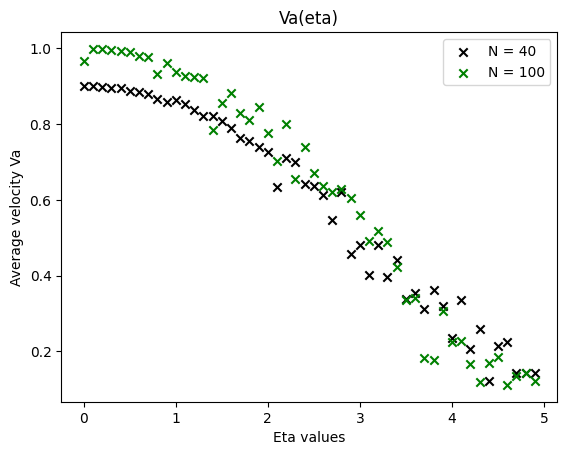

In [17]:
### Computing Va(eta)

List_of_Ns = [40,100] #,200,400]

List_of_Vas = [[] for N in List_of_Ns] # This list will hold the values that are to be printed out in the end for the various N values
NbOfPlotPoints = 50
List_of_etas = np.arange(0,5,5/NbOfPlotPoints)

for N in List_of_Ns :

  index = List_of_Ns.index(N)

  for i in range(len(List_of_etas)):

    Vas_for_eta = [] # This list will hold the Va values that will be averaged out at the end of the computation for each specific eta value

    # Parameters

    rho = 0.2
    eta = List_of_etas[i]
    visionRadius = FacteurDeTaille*3.0
    # I tried using a wider vision radius to see if it would smoothen out the final data, see provided graphs

    NumberOfFrams = 140

    V = N/rho
    L = FacteurDeTaille*np.sqrt(V)

    ### Initializing the various datasets as per usual

    NumberOfPoints = len(np.arange(3,L,L/np.sqrt(N)))
    RandomX, RandomY = np.random.uniform(3,L,(1,NumberOfPoints))[0],np.random.uniform(3,L,(1,NumberOfPoints))[0]
    InitialX, InitialY = np.meshgrid(RandomX,RandomY)

    Coord_data_ellipses = [np.column_stack((InitialX.ravel(), InitialY.ravel()))]
    Orientation_data = [np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))]
    Coord_X, Coord_Y = [InitialX],[InitialY]

    Orientations = np.random.uniform(0, 2*np.pi, int(np.sqrt(N))*int(np.sqrt(N)))

    ### Since there is no animation here, we can forgo the entire HTML writing and simply run a for loop

    for frames in range(NumberOfFrams):
      Vas_for_eta = updateFrameNoAnim(frames,Coord_data_ellipses,Orientation_data,Coord_X,Coord_Y,Vas_for_eta)

    List_of_Vas[index].append(sum(Vas_for_eta)/len(Vas_for_eta))


plt.scatter(List_of_etas,List_of_Vas[0],color='k',marker = 'x',label ='N = 40')
plt.scatter(List_of_etas,List_of_Vas[1],color='g',marker = 'x',label ='N = 100')
#plt.scatter(List_of_etas,List_of_Vas[2],color='b',marker = 'x',label ='N = 200')
#plt.scatter(List_of_etas,List_of_Vas[3],color='r',marker = 'x',label ='N = 400')
plt.xlabel('Eta values')
plt.ylabel('Average velocity Va')
plt.title('Va(eta)')
plt.legend()
plt.show()

Considering the computation time for N = 200 alone would be around 40 * 140 * 0.4 = 2240 seconds i.e. 37 mins, I choose to stop the computation at only N = 40 and N = 100, since it already allows us to see the general trend, that being the phase transition and the shift between ordered and disordered for eta between 2 and 3.

Increasing the vision radius seems to help smoothen out the values (cf graphs) but delays the apparition of a disordered state.